# Results

### Libraries

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from abc import ABC, abstractmethod
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
save_figures = True

In [3]:
from option import CallOption, PutOption
from underlying import GeometricBrownianMotion
from delta_hedge import DeltaHedgingEngine

### Market Parameters

In [4]:
spot = 100 # $100
strike = 100 # $100
maturity = 1 # 1 year
rate = 0.05 # 5%
sigma = 0.2 # 20%
drift = 0.3 # 30%

### Underlying Model

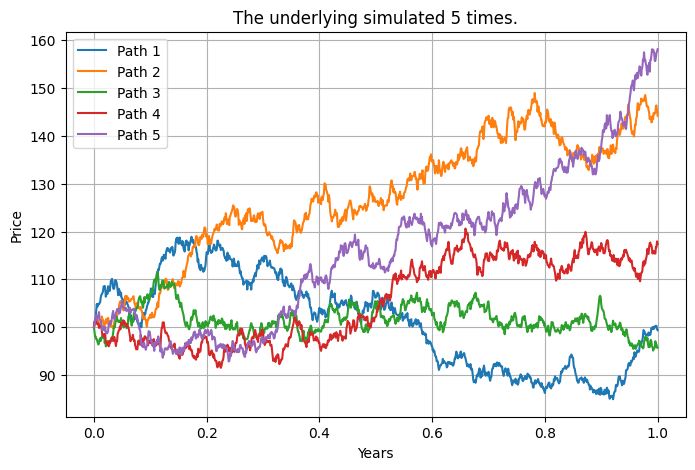

In [5]:
mesh = 1/1000
runs = 5

asset = GeometricBrownianMotion(spot, drift, sigma)

paths = asset.simulate(maturity, runs, mesh)
time_axis = np.linspace(0, maturity, len(paths[0]))

plt.figure(figsize=(8,5))
for j in range(runs):
    plt.plot(time_axis, paths[j], label=f"Path {j+1}")

plt.title(f"The underlying simulated {runs} times.")
plt.xlabel("Years")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/gbm_samples.png')

### Option Payoff, Price, & Delta Plots

In [6]:
start = 1
end = 200
n_pts = ((end - start) // start) + 1
spot_axis = np.linspace(start, end, n_pts)

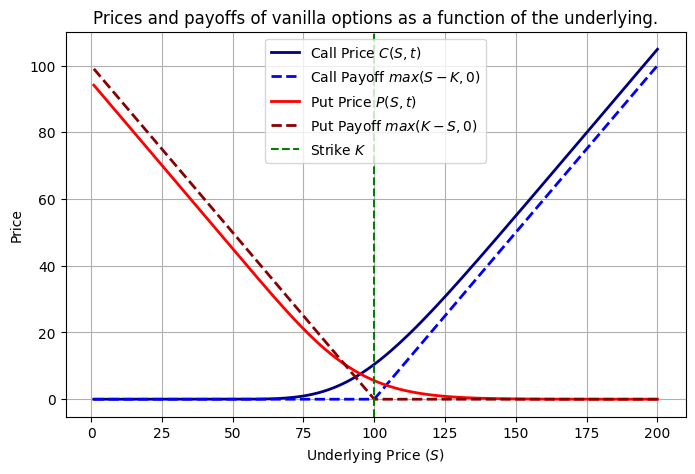

In [7]:
call = CallOption(strike, maturity)
put = PutOption(strike, maturity)

plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.price(spot_axis, 0, rate, sigma), color='navy', label=r"Call Price $C(S,t)$", linewidth=2)
plt.plot(spot_axis, call.payoff(spot_axis), '--', color='blue', label=r"Call Payoff $max(S-K,0)$", linewidth=2)
plt.plot(spot_axis, put.price(spot_axis, 0, rate, sigma), color='red', label=r"Put Price $P(S,t)$", linewidth=2)
plt.plot(spot_axis, put.payoff(spot_axis), '--', color='darkred', label=r"Put Payoff $max(K-S,0)$", linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label=r"Strike $K$")
plt.xlabel(r"Underlying Price ($S$)")
plt.ylabel("Price")
plt.title("Prices and payoffs of vanilla options as a function of the underlying.")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/put_call.png')

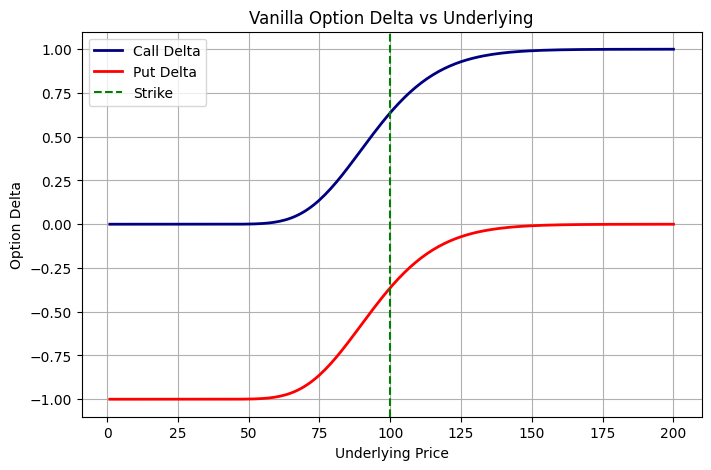

In [8]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.delta(spot_axis, 0, rate, sigma), color='navy', label="Call Delta", linewidth=2)
plt.plot(spot_axis, put.delta(spot_axis, 0, rate, sigma), color='red', label="Put Delta", linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label="Strike")
plt.xlabel("Underlying Price")
plt.ylabel("Option Delta")
plt.title("Vanilla Option Delta vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/put_call_delta_parity.png')

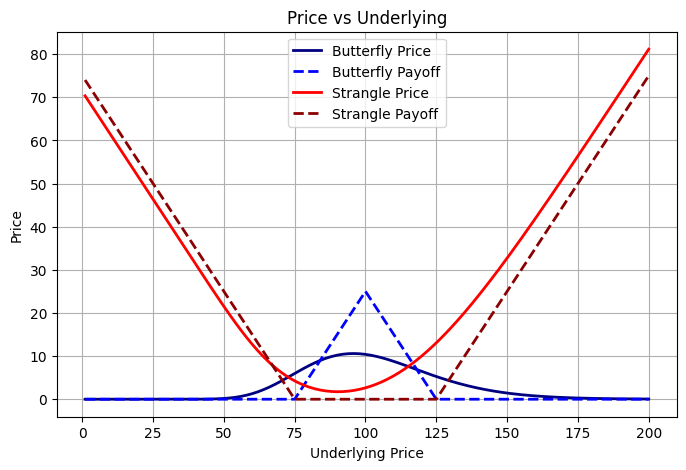

In [9]:
bull_call = CallOption(90,1) - CallOption(110,1)
butterfly = CallOption(75, 1) - 2*CallOption(100, 1) + CallOption(125, 1)
call_condor = CallOption(50,1) - CallOption(60,1) - CallOption(140,1) + CallOption(150,1)
straddle = CallOption(100,1) + PutOption(100,1)
strangle = CallOption(125,1) + PutOption(75,1)

combo_option_1 = butterfly
combo_option_2 = strangle

plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.price(spot_axis, 0, rate, sigma), color='navy', label="Butterfly Price", linewidth=2)
plt.plot(spot_axis, combo_option_1.payoff(spot_axis), '--', color='blue', label="Butterfly Payoff", linewidth=2)
plt.plot(spot_axis, combo_option_2.price(spot_axis, 0, rate, sigma), color='red', label="Strangle Price", linewidth=2)
plt.plot(spot_axis, combo_option_2.payoff(spot_axis), '--', color='darkred', label="Strangle Payoff", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Price")
plt.title("Price vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/linear_options.png')

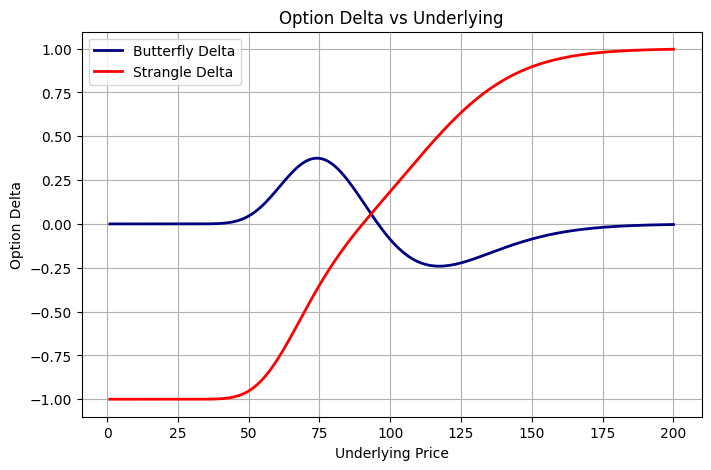

In [10]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.delta(spot_axis, 0, rate, sigma), color='navy', label="Butterfly Delta", linewidth=2)
plt.plot(spot_axis, combo_option_2.delta(spot_axis, 0, rate, sigma), color='red', label="Strangle Delta", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Option Delta")
plt.title("Option Delta vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/linear_option_deltas.png')

### Discrete Delta Hedging Simulation

In [11]:
runs = 1000
option = call

In [12]:
mesh = 1/10
path_index = 0

hedging_results = DeltaHedgingEngine(option, asset).run(rate, sigma, runs, mesh)

### Pathwise Simulation Plots

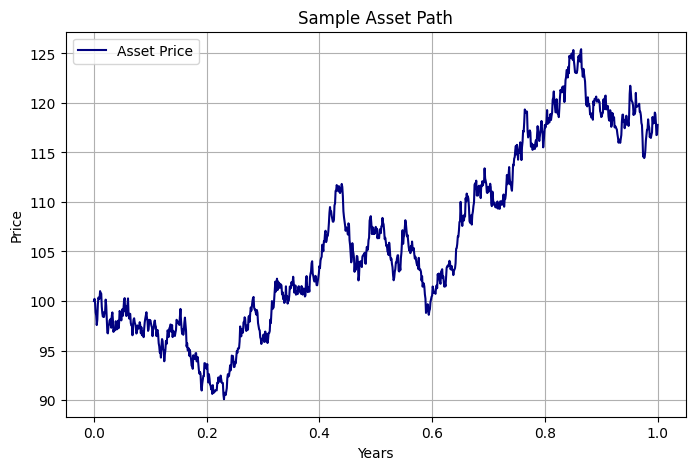

In [13]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.underlying[path_index], color='navy', label=f"Asset Price")

plt.title("Sample Asset Path")
plt.xlabel("Years")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/asset_path.png')

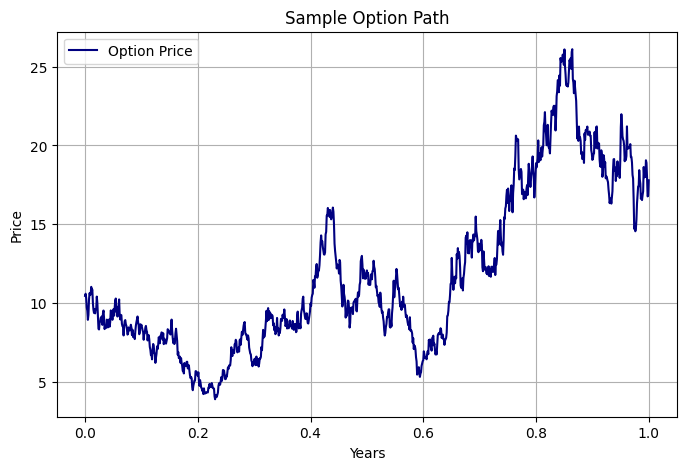

In [14]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.option[path_index], color='navy', label=f"Option Price")

plt.title("Sample Option Path")
plt.xlabel("Years")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/option_path.png')

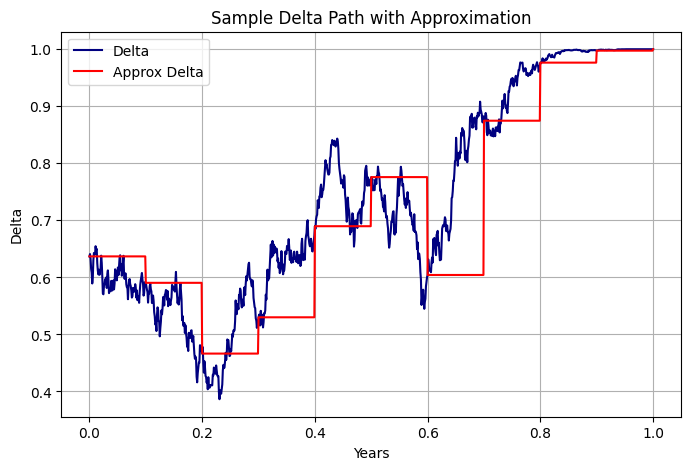

In [15]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.true_delta[path_index], color='navy', label=f"Delta")
plt.plot(hedging_results.time, hedging_results.approx_delta[path_index], color='red', label=f"Approx Delta")

plt.title("Sample Delta Path with Approximation")
plt.xlabel("Years")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/delta_and_approx_paths.png')

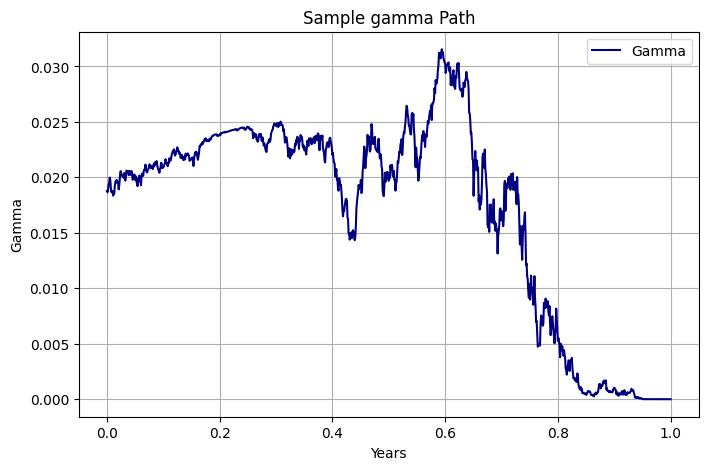

In [16]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.gamma[path_index], color='navy', label=f"Gamma")

# gamma tend to zero at maturity if the option is deep ITM/OTM. gamma blows up at maturity if ATM.
plt.title("Sample gamma Path")
plt.xlabel("Years")
plt.ylabel("Gamma")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/gamma_path.png')

### Discrete Delta Hedging Error (P&L)

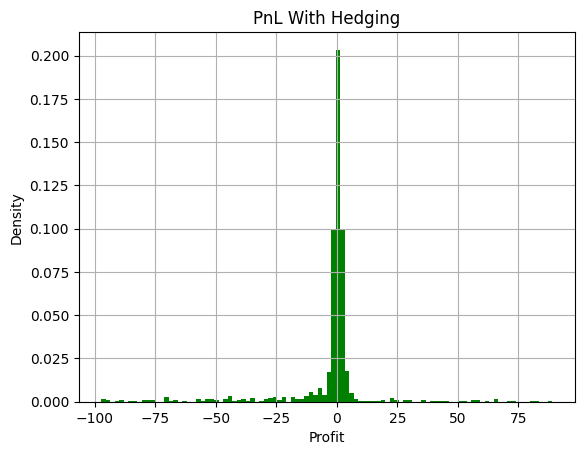

In [17]:
plt.hist(hedging_results.pnl, bins=100, density=True, color='green')

plt.title("PnL With Hedging")
plt.xlabel("Profit")
plt.ylabel("Density")
plt.grid(True)
if save_figures:
    plt.savefig('../figures/PnL_with_hedge.png')

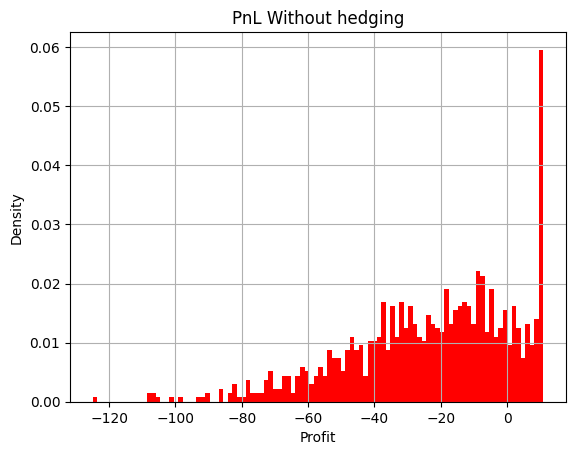

In [18]:
current_asset_price = np.zeros(runs)
current_asset_price[:] = asset.simulate(maturity, runs, mesh)[:,0]
final_asset_price = np.zeros(runs)
final_asset_price[:] = asset.simulate(maturity, runs, mesh)[:,-1]
no_hedge_pnl = option.price(current_asset_price, 0, rate, sigma)*np.exp(rate*maturity) - option.payoff(final_asset_price)

plt.hist(no_hedge_pnl, bins=100, density=True, color='red')

plt.title("PnL Without hedging")
plt.xlabel("Profit")
plt.ylabel("Density")
plt.grid(True)
if save_figures:
    plt.savefig('../figures/PnL_without_hedge.png')

In [19]:
print(f'No hedging: Mean PnL= {np.mean(no_hedge_pnl):.2f}, Stddev PnL= {np.std(no_hedge_pnl):.6f}')
print(f'Hedging: Mean PnL= {np.mean(hedging_results.pnl):.2f}, Stddev PnL= {np.std(hedging_results.pnl):.6f}')

No hedging: Mean PnL= -22.99, Stddev PnL= 24.687842
Hedging: Mean PnL= -2.48, Stddev PnL= 18.220606


### Convergence Test

In [20]:
dt_values = 1 / (2 ** np.arange(10))
pnl_var = []

for dt in dt_values:
    hedging_results = DeltaHedgingEngine(option, asset).run(rate, sigma, runs, dt)
    v = np.var(hedging_results.pnl)
    pnl_var.append(v)

pnl_var = [float(_) for _ in pnl_var]

Estimated convergence rate: 0.502


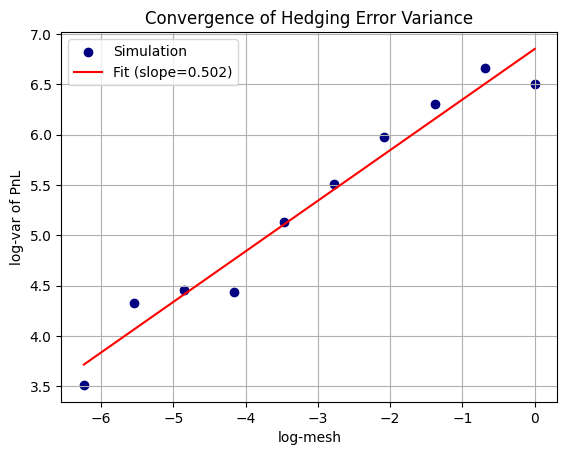

In [21]:
log_dt = np.log(np.array(dt_values))
log_var = np.log(np.array(pnl_var))

slope, intercept = np.polyfit(log_dt, log_var, 1)

print(f"Estimated convergence rate: {slope:.3f}")

plt.scatter(log_dt, log_var, color='navy', label="Simulation")
plt.plot(log_dt, slope*log_dt + intercept, color='red', label=f"Fit (slope={slope:.3f})")

plt.xlabel("log-mesh")
plt.ylabel("log-var of PnL")
plt.legend()
plt.title("Convergence of Hedging Error Variance")
plt.grid(True)
if save_figures:
    plt.savefig('../figures/loglog_plot_of_error_vs_dt.png')